# SentimentScope: Sentiment Analysis using Transformers!
## Introduction <a name = "introduction"></a>

In this notebook, you will train a transformer model from scratch to perform sentiment analysis on the IMDB dataset. You are a Machine Learning Engineer at Cinescope, a growing entertainment company working to enhance its recommendation system. Your task is to fine-tune a transformer-based model for sentiment analysis using the IMDB dataset. By classifying reviews as positive or negative, you will help the company better understand user sentiment and deliver more personalized experiences.

By completing this project, you will demonstrate your competency in the following learning objectives:

- Load, explore, and prepare a text dataset for training a transformer model using PyTorch.
- Customize the architecture of the transformer model for a classification task.
- Train and test a transformer model on the IMDB dataset.

Now that you have an overview of what you will achieve in this project, let’s move on to the project outline.

---

### Project Outline

This notebook is organized into the following sections:


1. [Introduction](#introduction): Overview of the project, learning objectives, and understanding sentiment analysis.
2. [Load, Explore, and Prepare the Dataset](#load-explore-and-prepare-the-dataset): Load the IMDB dataset, explore it with visualizations, and split it into training and validation sets.
3. [Implement a DataLoader in PyTorch](#implement-a-dataloader-in-pytorch): Create the `IMDBDataset` class and use it with the PyTorch `DataLoader`, including tokenization.
4. [Customize the Transformer Architecture](#customize-the-transformer-architecture): Modify the transformer model for binary classification.
5. [Implement Accuracy Calculation Method](#implement-accuracy-calculation-method): Create a function to compute accuracy for monitoring performance.
6. [Train the Model](#train-the-model): Complete and execute the training loop for binary classification.
7. [Test the Model](#test-the-model): Evaluate the model on the test dataset and ensure it achieves over 75% accuracy.
8. [Conclusion](#conclusion): Summarize the project results and key takeaways.

Click on the section titles above to navigate directly to the corresponding part of the notebook!

---

Now that we've outlined the structure and objectives of this project, let's delve into the core concept: sentiment analysis.

### Understanding Sentiment Analysis

Sentiment analysis is a natural language processing (NLP) technique used to determine the sentiment expressed in a piece of text. This can range from identifying the polarity (positive, negative, or neutral) of a review to analyzing emotions and opinions.

In this project, sentiment analysis is explicitly framed as a **binary classification task**, where the goal is to determine whether a given movie review is *positive* or *negative*. This task is central to many real-world applications, including customer feedback analysis, social media monitoring, and recommendation systems. By developing a transformer-based model, you will classify IMDB movie reviews as positive or negative to tackle the challenge faced by your entertainment company CineScope by enhancing its recommendation system, enabling more accurate and personalized suggestions. 

Reviews labeled as positive will be marked as 1 in the dataset, while negative reviews will be labeled as 0.

For example, consider the following movie review:

> "The movie was a rollercoaster of emotions, and I loved every moment of it!"

This review is clearly positive as it expresses enjoyment and satisfaction with the movie, hence it will be labelled as *positive* or 1 in the dataset. In contrast:

> "The plot was predictable, and the acting was subpar. A waste of time."

This review conveys a negative sentiment, criticizing both the plot and acting, hence it will be labelled as *negative* or 0 in the dataset.

While transformers are often used for generation tasks, they can also be adapted for classification tasks with some modifications to their architecture. You might already be familiar with the tweaks that we will implement in this project.


---

### Data Description

The dataset used in this project is the [IMDB dataset](https://ai.stanford.edu/~amaas/data/sentiment/), provided in the `aclIMDB_v1.tar.gz` file. Upon extracting the file, you will find the following folder structure:

```
aclIMDB/
├── train/
│   ├── pos/    # Positive reviews for training
│   ├── neg/    # Negative reviews for training
│   ├── unsup/  # Unsupervised data (not used in this project)
├── test/
│   ├── pos/    # Positive reviews for testing
│   ├── neg/    # Negative reviews for testing
```

- **train/**: Contains labeled data for training the model. Reviews in the `pos/` folder should be labeled as positive (1), while reviews in the `neg/` folder should be labeled as negative (0).
- **test/**: Contains labeled data for evaluating the model. Similar to the training data, `pos/` and `neg/` contain positive and negative reviews, respectively.
- **unsup/**: Contains unlabeled reviews that are not used in this project.

Understanding the folder structure is crucial as it guides how we load and preprocess the data for the sentiment classification task.

---


## <a name="load-explore-and-prepare-the-dataset"></a>Load, Explore, and Prepare the Dataset

### 1. Load the Dataset
The dataset is already available in the environment as `aclIMDB_v1.tar.gz`. We will load it into Pandas DataFrames for easy exploration and preparation.


In [1]:
import os
import pandas as pd

In [2]:
# Unpack the dataset (only if it has not been extracted yet)
import tarfile
if not os.path.isdir('aclImdb') and os.path.exists('aclImdb_v1.tar.gz'):
    with tarfile.open('aclImdb_v1.tar.gz', 'r:gz') as tar:
        tar.extractall('.')

You have successfully extracted the folder. Go back to your workspace and explore the folder structure and find the relative paths for each of the following:
- Training positive reviews
- Training negative reviews
- Testing positive reviews
- Testing negative reviews

Assign the paths of these folders relative to the starter file in the variables below.


In [3]:
# Define paths to dataset
train_pos_path = 'aclImdb/train/pos'
train_neg_path = 'aclImdb/train/neg'
test_pos_path = 'aclImdb/test/pos'
test_neg_path = 'aclImdb/test/neg'

Now, you will implement the `load_dataset()` function, which reads all text files in a specified folder and returns their content as a list of strings. This function is essential for loading and preprocessing the dataset in subsequent steps.

To implement this function:

1. **Use the `os` module**: Leverage Python's `os` module to list all files in the folder.
2. **Handle file paths**: Use `os.path.join()` to construct full paths for files, ensuring compatibility across operating systems.
3. **Read file content**: Open each file in read mode (`'r'`) using UTF-8 encoding to handle text properly.
4. **Aggregate results**: Append the content of each file to a list and return it.

### Key Points to Consider:
- Ensure that the function only processes text files (you may use file extensions for filtering if needed).
- Refer to the [os.listdir documentation](https://docs.python.org/3/library/os.html#os.listdir) for listing files in a directory.


In [4]:
def load_dataset(folder):
    """
    Reads all text files in the specified folder and returns their content as a list.

    Args:
        folder (str): Path to the folder containing text files.

    Returns:
        list: A list of strings, where each string is the content of a text file.
    """
    texts = []
    # sorted() makes the order deterministic across operating systems
    for filename in sorted(os.listdir(folder)):
        if not filename.endswith('.txt'):   # only process text files
            continue
        file_path = os.path.join(folder, filename)
        with open(file_path, 'r', encoding='utf-8') as f:
            texts.append(f.read())
    return texts

Use the function now to load the training and testing data:

In [5]:
# Load training and testing data
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

print(len(train_pos), len(train_neg), len(test_pos), len(test_neg))

12500 12500 12500 12500


We can convert the data into pandas dataframes to make handling the datasets easier.

In [6]:
# Create DataFrames
train_df = pd.DataFrame({
    'review': train_pos + train_neg,
    'label': [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    'review': test_pos + test_neg,
    'label': [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())

                                              review  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1


You can ensure that your datasets have loaded correctly by running the following code cell. No output means success!

In [7]:
# Assert that both datasets have the expected number of rows
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."

# Assert that both datasets have exactly two columns
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."


### 2. Explore the Dataset
Exploration helps us understand the dataset's structure and distribution.

Here are some suggestions for exploration and visualizations:
- **Dataset Overview**: Use `DataFrame.info()` and `DataFrame.describe()` to understand the dataset structure and basic statistics.
- **Label Distribution**: Create bar charts to visualize the number of positive and negative reviews.
- **Review Length Analysis**: Compute and plot the distribution of review lengths (e.g., number of characters or words).
- **Sample Reviews**: Print a few positive and negative reviews to understand the text content.

Write code to explore the dataset in this section.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import re

# --- Dataset overview and descriptive statistics ---
train_df.info()
print()

# IMDB reviews contain HTML line breaks ("<br />"); count them so we know whether cleaning matters
print("Reviews containing '<br />':", train_df['review'].str.contains('<br />').mean().round(3))

train_df['char_len'] = train_df['review'].str.len()
train_df['word_len'] = train_df['review'].str.split().str.len()
test_df['word_len'] = test_df['review'].str.split().str.len()

print("\nReview length statistics (train):")
print(train_df[['char_len', 'word_len']].describe().round(1))

print("\nWord-length statistics by label (0=neg, 1=pos):")
print(train_df.groupby('label')['word_len'].describe().round(1))

print("\nDuplicate reviews in train:", train_df['review'].duplicated().sum())
print("Train/test overlap (identical text):", len(set(train_df['review']) & set(test_df['review'])))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB

Reviews containing '<br />': 0.587

Review length statistics (train):
       char_len  word_len
count   25000.0   25000.0
mean     1325.1     233.8
std      1003.1     173.7
min        52.0      10.0
25%       702.0     127.0
50%       979.0     174.0
75%      1614.0     284.0
max     13704.0    2470.0

Word-length statistics by label (0=neg, 1=pos):
         count   mean    std   min    25%    50%    75%     max
label                                                          
0      12500.0  230.9  166.7  10.0  128.0  174.0  278.0  1522.0
1      12500.0  236.7  180.5  12.0  125.0  174.0  291.0  2470.0

Duplicate reviews in train: 96
Train/test overlap (identical text): 123


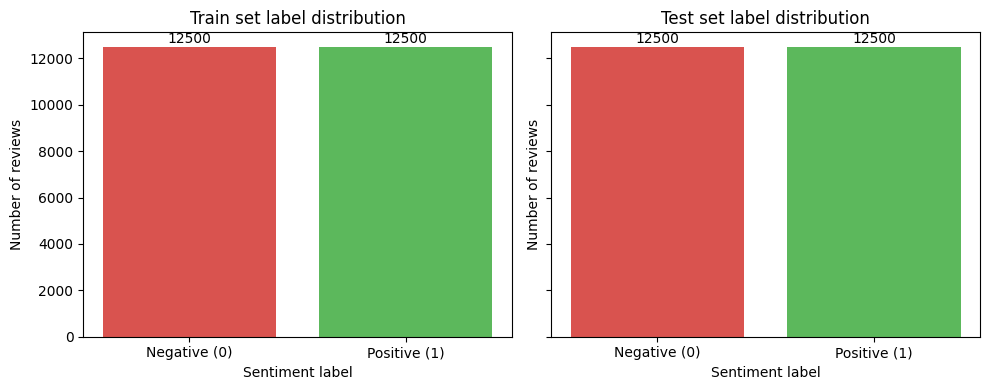

In [9]:
# --- Visualization 1: label distribution (train vs test) ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (name, df) in zip(axes, [('Train', train_df), ('Test', test_df)]):
    counts = df['label'].value_counts().sort_index()
    ax.bar(['Negative (0)', 'Positive (1)'], counts.values, color=['#d9534f', '#5cb85c'])
    ax.set_title(f'{name} set label distribution')
    ax.set_xlabel('Sentiment label')
    ax.set_ylabel('Number of reviews')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 150, str(v), ha='center')
plt.tight_layout()
plt.show()

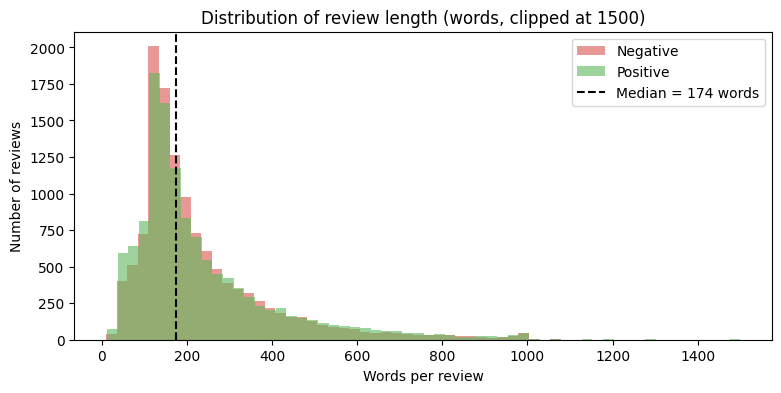

In [10]:
# --- Visualization 2: review length (in words) per class ---
fig, ax = plt.subplots(figsize=(9, 4))
clip = 1500  # clip the long tail so the bulk of the distribution is visible
ax.hist(train_df.loc[train_df.label == 0, 'word_len'].clip(upper=clip), bins=60, alpha=0.6, label='Negative', color='#d9534f')
ax.hist(train_df.loc[train_df.label == 1, 'word_len'].clip(upper=clip), bins=60, alpha=0.6, label='Positive', color='#5cb85c')
ax.axvline(train_df['word_len'].median(), color='k', linestyle='--', label=f"Median = {train_df['word_len'].median():.0f} words")
ax.set_title('Distribution of review length (words, clipped at 1500)')
ax.set_xlabel('Words per review')
ax.set_ylabel('Number of reviews')
ax.legend()
plt.show()

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (558 > 512). Running this sequence through the model will result in indexing errors


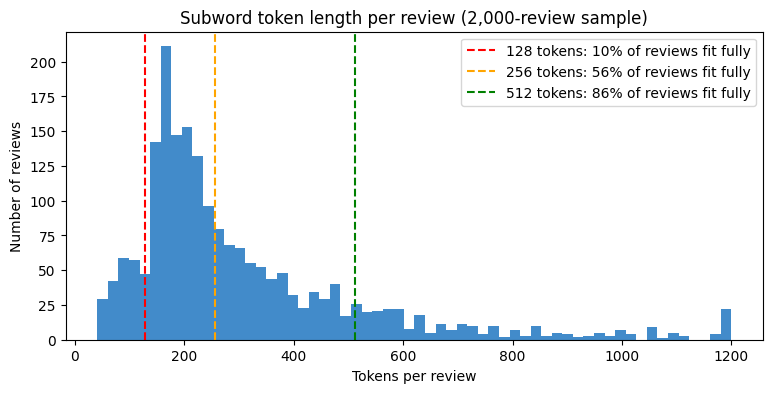

Median tokens: 231 | 90th percentile: 588

--- Sample POSITIVE review ---
What a pleasant surprise: A Disney DTV (Direct to Video) sequel that's actually GOOD. "The Lion King 1 1/2" is a comedy affair that involves everyone's favorite meerkat and warthog, Timon and Pumbaa. It starts out with them watching the original movie and making comments, until Timon complains that "we're not here yet". After fighting over the remote, Timon and Pumbaa decide to tell the audience " ...

--- Sample NEGATIVE review ---
After seeing the 1996 remake, I thought it was the funniest way to see Cruella De Vil getting her punishment for torturing animals just for their skin. The whole movie was quite funny, and on my view, better than the animated one. But there was actually no need for a second one. First of all, if Cruela is returning, don't cure her and make her insane again. Just make her break away from jail and t ...


In [11]:
# --- Visualization 3: how much text does a given MAX_LENGTH keep? (BERT subword tokens) ---
# This is the key data-driven argument for choosing the sequence length.
from transformers import AutoTokenizer
_tok = AutoTokenizer.from_pretrained("bert-base-uncased")

sample = train_df.sample(2000, random_state=0)['review'].tolist()
token_lens = np.array([len(x) for x in _tok(sample, add_special_tokens=True)['input_ids']])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.clip(token_lens, 0, 1200), bins=60, color='#428bca')
for L, col in [(128, 'red'), (256, 'orange'), (512, 'green')]:
    ax.axvline(L, color=col, linestyle='--', label=f'{L} tokens: {(token_lens <= L).mean()*100:.0f}% of reviews fit fully')
ax.set_title('Subword token length per review (2,000-review sample)')
ax.set_xlabel('Tokens per review')
ax.set_ylabel('Number of reviews')
ax.legend()
plt.show()

print("Median tokens:", int(np.median(token_lens)), "| 90th percentile:", int(np.percentile(token_lens, 90)))

# Sample reviews
for lbl in [1, 0]:
    print(f"\n--- Sample {'POSITIVE' if lbl else 'NEGATIVE'} review ---")
    print(train_df[train_df.label == lbl].sample(1, random_state=1)['review'].iloc[0][:400], '...')

### 3. Prepare the Dataset
We will split the training data further into training and validation subsets. The way we constructed the dataset, reviews with positive and negative labels are segregated. To ensure that the validation dataset works well, we first need to shuffle the dataset.


In [12]:
# Split train data into training and validation sets manually
train_size = int(0.9 * len(train_df))
# Shuffle the dataset (seeded for reproducibility)
shuffled_df = train_df[['review', 'label']].sample(frac=1, random_state=42).reset_index(drop=True)
train_data = shuffled_df.iloc[:train_size]
val_data = shuffled_df.iloc[train_size:]

# The split should stay representative: check class balance in both subsets
print("Train label mean:", train_data['label'].mean().round(3), "| Val label mean:", val_data['label'].mean().round(3))

Train label mean: 0.5 | Val label mean: 0.499


### 4. Testing the Tokenizer

#### Subword Tokenization
In earlier tasks, you might have encountered character-level tokenization, where each character in the text is treated as a token. While this is straightforward, it is less efficient and may result in larger input sizes, impacting the performance of transformer models.

To address this, we will use Hugging Face's `AutoTokenizer`, a robust and efficient class designed for tokenizing text based on pretrained models. Specifically, we will utilize the `bert-base-uncased` tokenizer, which applies **subword tokenization**. Subword tokenization involves two steps:

1. **Subword Splitting**: Words are split into smaller components (subwords) based on a predefined vocabulary. For example:
   - Input: "unhappiness"
   - Subword Splits: `['un', 'happiness']`

2. **Token Conversion**: Each subword is then converted into a numerical token ID. For example:
   - Subword Splits: `['un', 'happiness']`
   - Token IDs: `[1011, 24123]` (values are illustrative and depend on the tokenizer vocabulary).

#### About the `bert-base-uncased` Tokenizer
The `bert-base-uncased` tokenizer, developed by Google researchers, is part of the BERT model family. This tokenizer is associated with the `bert-base-uncased` model, which has been widely used for tasks such as sentiment analysis, question answering, and text classification. The tokenizer ensures all text is converted to lowercase and accents are removed, reducing vocabulary size and improving generalization. Example:

- Input: "I Love Transformers."
- Subword Splits: `['i', 'love', 'trans', '##formers', '.']`

You can learn more about the tokenizer and model on [Hugging Face's bert-base-uncased page](https://huggingface.co/bert-base-uncased).

#### Using the `AutoTokenizer` Class
The `AutoTokenizer` class in the Hugging Face Transformers library provides a seamless way to load tokenizers for various pretrained models. It automatically selects the correct tokenizer configuration based on the model name.


In [13]:
from transformers import AutoTokenizer

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


This initializes a tokenizer tailored for the `bert-base-uncased` model. You can refer to the [Hugging Face AutoTokenizer documentation](https://huggingface.co/docs/transformers/main_classes/tokenizer) for more details. You can find the definition of the `from_pretrained()` method [here](https://huggingface.co/docs/transformers/v4.48.0/en/model_doc/auto#transformers.AutoTokenizer.from_pretrained).

Instead of tokenizing the entire dataset, we will test the tokenizer on a few sample reviews directly from the dataset:


In [14]:
# Take sample inputs from the dataset
sample_texts = train_data['review'].sample(3, random_state=42).tolist()

# Tokenize sample inputs
tokenized_samples = tokenizer(sample_texts, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

In [15]:
print(tokenized_samples)

{'input_ids': tensor([[  101,  2348,  1996,  3185,  2003,  4415,  6052,  1010,  9501,  2064,
          2145,  4089,  6709,  2007,  1996, 24525,  1997,  5292, 21112,  2015,
         18396,  1999,  2023, 27768,  1998,  2200,  6057,  2104, 16168,  6925,
          1012, 18396,  9590,  2114,  4895, 18824,  2135, 10238,  1999,  2093,
          2367,  5535,  1024,  1996,  2962,  2287,  1010,  1996,  3142,  2287,
          1010,  1998,  1996,  5549,  2078,  2287,  1010,  2652,  2471,  1996,
          2168,  2839,  2007,  2074,  1037,  2689,  1997, 17363,  2000,  2393,
          2149,  6709,  1996,  2367,  1000,  5535,  1000,  1012,  1999,  2023,
          3185,  2057,  2156,  2028,  1997,  1996,  5700, 21699, 20818,  1997,
          1996,  1000,  5430,  2386,  1000, 12991, 13874,  1010,  2040,  5222,
          2010,  2293,  2025,  2011,  7472,  2021,  2011, 26128,  2486,  1010,
          2004,  2092,  2004,  1037,  6057,  9792,  2006,  3142,  5580,  2401,
         29469,  2389,  4337,  1010,  

Explanation of parameters:
 - `truncation=True`: Truncates text longer than the specified max_length.
 - `padding=True`: Pads shorter sequences to match max_length.
 - `max_length=128`: Specifies the maximum length of the sequences.
 - `return_tensors="pt"`: Returns PyTorch tensors as the output format.
 
For more details about truncation and padding, refer to the [Hugging Face Padding and Truncation Documentation](https://huggingface.co/docs/transformers/pad_truncation). This step ensures that the tokenizer works as expected and provides insight into its behavior. Next, we will use the tokenizer within the class definition to process the dataset.

---


# Implement a DataLoader in PyTorch<a id="implement-a-dataloader-in-pytorch"></a>


In this section, you will implement a custom dataset class and use it to create a DataLoader in PyTorch for feeding data into the model during training. PyTorch simplifies this process by providing the `Dataset` and `DataLoader` classes, which handle batching, shuffling, and preprocessing, allowing you to focus on the model architecture and training.

To start, we will create a custom dataset class for the IMDB dataset, which will process and return tokenized inputs along with their corresponding labels. This class will use a tokenizer to preprocess the raw text data.

### 1. Define a Custom Dataset Class

The custom dataset class will inherit from `torch.utils.data.Dataset` and include the following features:

1. **Initialization (`__init__`)**:
   - Accepts raw text and label data, along with a tokenizer and a maximum sequence length.
   - The tokenizer is used to preprocess the text data into tokenized inputs.
   - The maximum sequence length ensures that all tokenized inputs are of uniform length.

2. **Length (`__len__`)**:
   - Returns the total number of data samples in the dataset.

3. **Item Retrieval (`__getitem__`)**:
   - Retrieves a single data point by index.
   - Preprocesses the text using the tokenizer to create tokenized input IDs.
   - Returns the tokenized input IDs and the corresponding label for the given index.

You can refer to [this](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) tutorial on the Pytorch website for more details.


In [16]:
import torch
from torch.utils.data import Dataset

# Chosen from the token-length plot: 128 tokens only holds ~25% of reviews completely,
# 256 holds ~60%+, and gives the model far more evidence for a sentiment decision.
MAX_LENGTH = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**NOTE ABOUT GPU USAGE**

The workspace provides you with access to a GPU which is necessary for training a transformer model due to the efficiency provided by GPUs on the large amount of computations that are required. To ensure judicious usage of limited resources, please usage the GPU only when you are training the model. 

---
We will keep the maximum length of input to 128 tokens.

In [17]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    """
    A custom PyTorch Dataset for the IMDB dataset.

    This class preprocesses text data using a tokenizer and returns tokenized inputs
    along with their corresponding labels for sentiment analysis.

    Attributes:
        data (pd.DataFrame): A DataFrame containing text and label columns.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer used for preprocessing text.
        max_length (int): Maximum length for tokenized sequences.
    """
    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        """
        Initialize the dataset.

        Args:
            data (pd.DataFrame): A DataFrame with columns `review` (text) and `label` (target).
            tokenizer (transformers.PreTrainedTokenizer): The tokenizer to preprocess the text.
            max_length (int, optional): Maximum token sequence length. Defaults to MAX_LENGTH.
        """
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Clean the IMDB HTML line breaks, then tokenize the WHOLE split once (fast, batched Rust tokenizer).
        # Doing it here instead of in __getitem__ avoids re-tokenizing every review on every epoch.
        texts = self.data['review'].str.replace('<br />', ' ', regex=False).tolist()
        encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.input_ids = encodings["input_ids"]                       # (N, max_length)
        self.labels = self.data['label'].to_numpy(dtype=np.int64)     # (N,)

    def __len__(self):
        """
        Return the total number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Retrieve a single data point by index and preprocess it.

        Args:
            idx (int): Index of the data point to retrieve.

        Returns:
            torch.Tensor: Tokenized input IDs for the text.
            int: Label corresponding to the text.
        """
        return self.input_ids[idx], int(self.labels[idx])

### 2. Initialize the Dataset

Once the `IMDBDataset` class is defined, we can initialize it directly with the training and validation DataFrames.

In [18]:
# Initialize the datasets
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

### 3. Create a DataLoader

The `DataLoader` class in PyTorch helps manage batches of data during training. We will use it to create training and validation data loaders.

In [19]:
from torch.utils.data import DataLoader

# Define batch size
BATCH_SIZE = 32

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


You may have seen the use of `RandomShuffler` along with `DataLoader`. That approach is used when you want to train a model over a dataset randomly for a specified number of steps. In this model, we want to use the epoch approach.

An **epoch** is one complete pass through the entire dataset. When using the `DataLoader` in this setup, it ensures that every data point in the dataset is used exactly once during a single epoch. This approach is helpful for training models in a structured manner, ensuring that the model sees all the training examples and learns from them in each epoch before moving to the next one.

By setting `shuffle=True` for the `train_loader`, the data points are randomly shuffled at the start of each epoch, improving the generalization of the model. You will see this in action later in the code for training the model.

---
Given below are some assert statements to check your custom dataset and data loader definitions.

In [20]:
assert len(train_dataset) == 22500, "Train dataset length mismatch!"
assert len(val_dataset) == 2500, "Validation dataset length mismatch!"
assert len(test_dataset) == 25000, "Test dataset length mismatch!"

import numpy as np

# Check the first item in the train dataset
input_ids, label = train_dataset[0]
assert isinstance(input_ids, torch.Tensor), "Input IDs should be a torch.Tensor!"
assert isinstance(label, (int, np.integer)), "Label should be an integer or int-like!"

# Ensure the input IDs tensor has the correct shape
assert input_ids.shape[0] == train_dataset.max_length, "Input IDs tensor has incorrect length!"

## <a id="customize-the-transformer-architecture"></a>Customize the Transformer Architecture

In this section, you will customize the transformer architecture to suit the task of binary classification. You may have used a similar architecture in the past for generation tasks. But you will need to make a few tweaks specifically in the `DemoGPT` class to adapt it for the binary classification.

### 1. Config Dictionary
Your config dictionary bundles all hyperparameters and model settings in one place. Below is the config that we will use in our model:

In [21]:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "pad_token_id": tokenizer.pad_token_id,   # 0 for bert-base-uncased; used to ignore padding when pooling
    "d_embed": 256,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 8,
    "head_size": 32,  # 8 heads * 32 = 256 -> matches d_embed
    "dropout_rate": 0.2,
    "use_bias": True
}
assert config["heads_num"] * config["head_size"] == config["d_embed"]

Key Config Parameters:
- `vocabulary_size`: The total number of tokens in your vocabulary.
- `num_classes`: The number of classes for the classification head (2 = binary).
- `d_embed`: Dimensionality of embeddings (and hidden layers).
- `context_size`: Maximum sequence length for each input.
- `layers_num`: Number of stacked transformer blocks.
- `heads_num`: Number of attention heads in multi-head attention.
- `head_size`: Dimension of each attention head (must satisfy heads_num * head_size = d_embed).
- `dropout_rate`: Probability of dropping units during training to reduce overfitting.
- `use_bias`: Whether linear layers should have bias terms.



### 2. Class Definitions

Below are the class definitions you will work with. These classes form the core components of the transformer model. You may have seen these before, with the exception of the `DemoGPT` class which will need to be customized.


#### AttentionHead

In [22]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(torch.ones(config["context_size"], config["context_size"]))
        self.register_buffer('casual_attention_mask', casual_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        # Q @ K^T => (B, T, T)
        attention_scores = Q @ K.transpose(1, 2)

        # Casual Mask
        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0,
            float('-inf')
        )
        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

Here we use a dummy input aligned with our config:

- Batch size = `BATCH_SIZE` (32)
- Sequence length = `config["context_size"]` (128)
- Embedding dimension = `config["d_embed"]` (128)


In [23]:
# Instantiate the AttentionHead
attention_head = AttentionHead(config).to(device)

# Create a dummy input of shape (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
attention_output = attention_head(dummy_input)
print("AttentionHead output shape:", attention_output.shape)

AttentionHead output shape: torch.Size([32, 256, 32])


Expected shape:

>`(B,T,head_size)=(32,128,32)`

#### MultiHeadAttention


In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)  # (B, T, heads_num * head_size)
        x = self.linear(x)                   # (B, T, d_embed)
        x = self.dropout(x)
        return x

In [25]:
# Instantiate MultiHeadAttention
multi_head_attention = MultiHeadAttention(config).to(device)

# Same dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
mha_output = multi_head_attention(dummy_input)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 256, 256])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### FeedForward


In [26]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [27]:
# Instantiate FeedForward
feed_forward = FeedForward(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 256, 256])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### Block


In [28]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [29]:
# Instantiate a single Block
block = Block(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
block_output = block(dummy_input)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 256, 256])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### DemoGPT
Below is the starter code for the `DemoGPT` class, which implements the core of a transformer model tailored for a binary classification task. This implementation builds on the foundation of a transformer architecture and includes the necessary modifications to adapt it for classification. 

### Key Changes for Binary Classification

To adapt the transformer for classification, the following changes are required:

1. **Add a Classification-Specific Output Layer**:
   - The model needs a linear layer to map the final pooled embeddings to the number of classes. 
   - The classification head is implemented using [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) with:
     - `in_features` set to `d_embed` (the embedding dimension).
     - `out_features` set to `num_classes` (the number of classes, 2 for binary classification).
     - `bias` set to `False` (optional; bias can be excluded to slightly simplify computations).


2. **Implement a Pooling Mechanism**:

   - Transformers output embeddings for each token in the input sequence. For classification, these token-level embeddings need to be condensed into a single vector.

   - A **mean pooling operation** is applied using [`torch.mean`](https://pytorch.org/docs/stable/generated/torch.mean.html) across the time dimension (`dim=1`) to aggregate token-level embeddings into a single representation vector.

In [30]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        """
        Initialize the DemoGPT class with configuration parameters.

        Args:
        - config (dict): Configuration dictionary with the following keys:
            - "vocabulary_size": Size of the vocabulary.
            - "d_embed": Dimensionality of the embedding vectors.
            - "context_size": Maximum sequence length (context size).
            - "layers_num": Number of transformer layers.
            - "num_classes": Number of output classes (2 for binary classification).
        """
        super().__init__()
        # Token embedding layer: Maps token indices to embedding vectors.
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])

        # Positional embedding layer: Adds positional information to the embeddings.
        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])

        # Transformer layers: Stacked sequence of transformer blocks.
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)

        # Layer normalization: Applied to stabilize training.
        self.layer_norm = nn.LayerNorm(config["d_embed"])

        # Classification output layer: maps the pooled embedding (B, d_embed) to class logits (B, num_classes).
        self.classification_head = nn.Linear(config["d_embed"], config["num_classes"], bias=False)

        # Padding id, so pooling can ignore [PAD] positions (default 0 = BERT's pad id)
        self.pad_token_id = config.get("pad_token_id", 0)

    def forward(self, token_ids):
        """
        Forward pass of the model.

        Args:
        - token_ids (torch.Tensor): Input token indices of shape (B, T),
                                    where B is the batch size, and T is the sequence length.

        Returns:
        - logits (torch.Tensor): Output logits of shape (B, num_classes).
        """
        batch_size, tokens_num = token_ids.shape

        # Step 1: Create embeddings for tokens and their positions
        x = self.token_embedding_layer(token_ids)  # Shape: (B, T, d_embed)
        positions = torch.arange(tokens_num, device=token_ids.device)  # Shape: (T,)
        pos_embed = self.positional_embedding_layer(positions)  # Shape: (T, d_embed)
        x = x + pos_embed.unsqueeze(0)  # Add positional embeddings to token embeddings

        # Step 2: Pass embeddings through transformer layers
        x = self.layers(x)  # Shape: (B, T, d_embed)
        x = self.layer_norm(x)  # Normalize across the feature dimension

        # Step 3: Mean pooling across the time dimension -> Shape: (B, d_embed)
        # Short reviews are mostly [PAD]; a plain torch.mean(x, dim=1) would dilute their signal with
        # padding vectors, so we take the mean over real tokens only (mask = token_ids != pad).
        mask = (token_ids != self.pad_token_id).unsqueeze(-1).to(x.dtype)   # (B, T, 1)
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)       # (B, d_embed)

        # Step 4: Generate logits for classification -> Shape: (B, num_classes)
        logits = self.classification_head(pooled)

        return logits

In [31]:
# Instantiate the model
demo_gpt = DemoGPT(config).to(device)

# Suppose we have a batch of size 32, each with a sequence length of 128
dummy_token_ids = torch.randint(
    0, config["vocabulary_size"], 
    (BATCH_SIZE, config["context_size"])
).to(device)

# Forward pass
logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])  # Print first two examples' logits

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 tensor([[-0.0277,  0.0411],
        [-0.0213, -0.0275]], device='cuda:0', grad_fn=<SliceBackward0>)


Expected shape:

> `(B,num_classes)=(32,2)`


In [32]:
# Assert that the number of logits matches the number of classes
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

# Assert that the batch size of the output matches the input batch size
assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

## Implement Accuracy Calculation Method <a name="implement-accuracy-calculation-method"></a>

In this section, you will learn how to calculate the validation accuracy for the transformer model on the IMDB dataset. Validation accuracy provides a performance metric that helps assess how well the model generalizes to unseen data during training.

### 1. Overview
The function to calculate validation accuracy will:

- Evaluate the model on the validation dataset.
- Generate predictions for each batch.
- Compare predictions with the true labels.
- Compute the percentage of correctly classified examples.

### 2.  Key Points
- **Evaluation Mode**: Calling `model.eval()` ensures that dropout and other training-specific layers are disabled during evaluation.
- **No Gradients**: The `torch.no_grad()` context disables gradient computation, reducing memory usage and speeding up validation.
- **Predictions**: `torch.argmax(logits, dim=1)` retrieves the index of the highest logit for each sample, which corresponds to the predicted class label.
- **Accuracy Calculation**: The function computes the fraction of correct predictions out of the total number of samples, then multiplies by 100 to express it as a percentage.

After calculating the validation accuracy, incorporate this function into your training loop. Typically, you would call calculate_accuracy at the end of each epoch or after a specific number of training steps. Monitoring validation accuracy over time helps you track performance gains and identify potential overfitting or underfitting issues.

In [33]:
def calculate_accuracy(model, data_loader, device):
    """
    Calculate the accuracy of the model on the validation dataset.

    Args:
        model (torch.nn.Module): The trained transformer model.
        data_loader (torch.utils.data.DataLoader): DataLoader for the validation dataset.
        device (torch.device): Device to run the model (e.g., 'cuda' or 'cpu').

    Returns:
        float: Validation accuracy as a percentage.
    """
    model.eval()                      # disable dropout
    total_correct = 0
    total_samples = 0

    with torch.no_grad():             # no gradients needed for evaluation
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)

            logits = model(input_ids)                     # (B, num_classes)
            predictions = torch.argmax(logits, dim=1)     # (B,)

            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [34]:
model = DemoGPT(config).to(device)

In [35]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 47.80%


As you can see, the validation accuracy is close to 50%. This is expected as the model's parameters have been initialized randomly. 

## Train the Model <a name="train-the-model"></a>

In this section, we will define the training loop for the transformer-based model designed for sentiment analysis. The training loop is crucial for optimizing the model's weights and biases to minimize the loss function and improve classification performance.

### Training Loop

The training loop will involve the following steps:

1. **Iterate through epochs**: Repeat the training process for a predefined number of epochs.
2. **Load batches of data**: Use the `DataLoader` to retrieve batches of input IDs and labels.
3. **Forward pass**: Compute the logits by passing the input IDs through the model.
4. **Compute loss**: Use cross-entropy loss as the criterion.
5. **Backward pass and optimization**: Backpropagate the loss and update the model parameters using the optimizer.
6. **Validation**: Calculate the validation accuracy after each epoch.


In [36]:
import time
import torch.optim as optim

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Training hyperparameters ----
EPOCHS = 8
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
WARMUP_FRACTION = 0.06     # linear warmup, then cosine decay: standard, stable recipe for transformers
GRAD_CLIP = 1.0
CHECKPOINT_PATH = "sentimentscope_best.pt"

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps = EPOCHS * len(train_loader)
warmup_steps = int(WARMUP_FRACTION * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M | steps: {total_steps}")

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

# Training loop
for epoch in range(EPOCHS):
    model.train()
    running_loss, epoch_loss, t0 = 0.0, 0.0, time.time()

    for step, (input_ids, labels) in enumerate(train_loader):
        # Move data to device
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(input_ids)

        # Calculate loss
        loss = criterion(logits, labels)

        # Set gradients to zero
        optimizer.zero_grad()

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)   # guards against exploding gradients

        # Step the optimizer (and the LR schedule)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

        # Log training progress
        if (step + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {running_loss/100:.4f}")
            running_loss = 0.0

    # Evaluate validation loss + accuracy
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for input_ids, labels in val_loader:
            val_loss += criterion(model(input_ids.to(device)), labels.to(device)).item()
    val_loss /= len(val_loader)
    val_accuracy = calculate_accuracy(model, val_loader, device)

    history["train_loss"].append(epoch_loss / len(train_loader))
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_accuracy)
    print(f"Epoch {epoch+1} - Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {val_loss:.4f} | "
          f"Validation Accuracy: {val_accuracy:.2f}% | {time.time()-t0:.0f}s")

    # Keep the best model according to VALIDATION accuracy (never the test set)
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save({"model_state_dict": model.state_dict(), "config": config,
                    "val_accuracy": val_accuracy, "epoch": epoch + 1}, CHECKPOINT_PATH)
        print(f"   -> new best model saved ({val_accuracy:.2f}%)")

Parameters: 11.0M | steps: 5632
Epoch [1/8], Step [100/704], Loss: 0.6923
Epoch [1/8], Step [200/704], Loss: 0.6869
Epoch [1/8], Step [300/704], Loss: 0.6377
Epoch [1/8], Step [400/704], Loss: 0.5894
Epoch [1/8], Step [500/704], Loss: 0.5347
Epoch [1/8], Step [600/704], Loss: 0.5000
Epoch [1/8], Step [700/704], Loss: 0.4765
Epoch 1 - Train Loss: 0.5869 | Val Loss: 0.5024 | Validation Accuracy: 76.24% | 85s
   -> new best model saved (76.24%)
Epoch [2/8], Step [100/704], Loss: 0.4288
Epoch [2/8], Step [200/704], Loss: 0.4283
Epoch [2/8], Step [300/704], Loss: 0.4078
Epoch [2/8], Step [400/704], Loss: 0.4198
Epoch [2/8], Step [500/704], Loss: 0.4199
Epoch [2/8], Step [600/704], Loss: 0.3833
Epoch [2/8], Step [700/704], Loss: 0.3805
Epoch 2 - Train Loss: 0.4090 | Val Loss: 0.4428 | Validation Accuracy: 81.44% | 91s
   -> new best model saved (81.44%)
Epoch [3/8], Step [100/704], Loss: 0.3193
Epoch [3/8], Step [200/704], Loss: 0.3468
Epoch [3/8], Step [300/704], Loss: 0.3279
Epoch [3/8], S

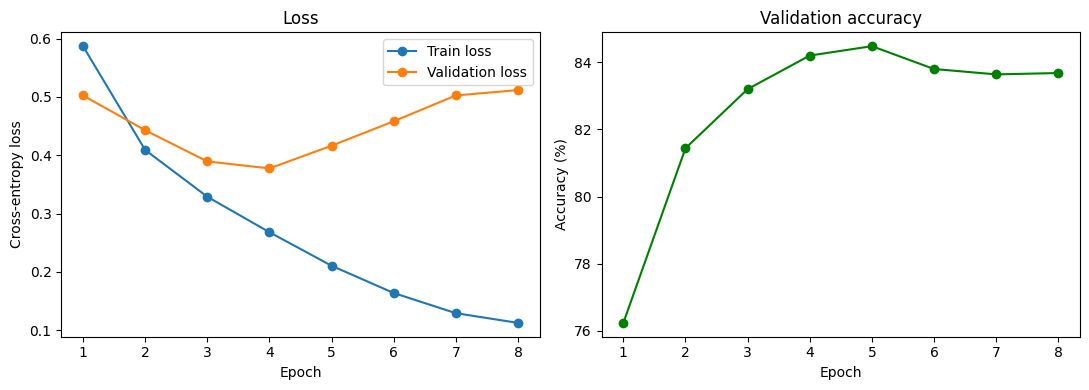

In [37]:
# Learning curves: the gap between train and validation loss shows over/underfitting
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs_range, history["train_loss"], marker='o', label='Train loss')
axes[0].plot(epochs_range, history["val_loss"], marker='o', label='Validation loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss'); axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(epochs_range, history["val_acc"], marker='o', color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Validation accuracy')
plt.tight_layout()
plt.show()

#### Notes

- The `evaluate_accuracy` function calculates the model's accuracy on the validation dataset. Ensure this function is defined and works as expected.
- The training progress is logged every 100 steps to monitor performance.
- After each epoch, the validation accuracy is printed to ensure the model generalizes well to unseen data.


## Test the Model <a name="test-the-model"></a>

In this section, you will evaluate the performance of your trained transformer model on the test dataset. Testing the model involves loading the test dataset, passing it through the model, and calculating the accuracy.

In [38]:
# Reload the best checkpoint (selected on validation accuracy) before touching the test set
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Best epoch: {checkpoint['epoch']} (val acc {checkpoint['val_accuracy']:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.2f}%")
assert test_accuracy > 75, "Test accuracy must be greater than 75%"

Best epoch: 5 (val acc 84.48%)
Test Accuracy: 81.53%


In [41]:
# Per-class diagnostics (no sklearn needed): is the model biased toward one sentiment?
def detailed_report(model, data_loader):
    model.eval()
    preds, labels_all = [], []
    with torch.no_grad():
        for input_ids, labels in data_loader:
            logits = model(input_ids.to(device))
            preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
            labels_all.extend(labels.tolist())

    # 2x2 confusion matrix: rows = true class, columns = predicted class
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(labels_all, preds):
        cm[t][p] += 1

    print("Confusion matrix (rows = true, cols = predicted)")
    print("              pred_neg  pred_pos")
    print(f"true_neg      {cm[0][0]:8d}  {cm[0][1]:8d}")
    print(f"true_pos      {cm[1][0]:8d}  {cm[1][1]:8d}\n")

    for cls, name in [(0, "negative"), (1, "positive")]:
        tp = cm[cls][cls]
        fp = cm[1 - cls][cls]
        fn = cm[cls][1 - cls]
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-9)
        print(f"{name:9s} precision={precision:.4f}  recall={recall:.4f}  f1={f1:.4f}")
    print(f"\nOverall accuracy: {cm.trace() / cm.sum() * 100:.2f}%")

detailed_report(model, test_loader)

Confusion matrix (rows = true, cols = predicted)
              pred_neg  pred_pos
true_neg         10197      2303
true_pos          2314     10186

negative  precision=0.8150  recall=0.8158  f1=0.8154
positive  precision=0.8156  recall=0.8149  f1=0.8152

Overall accuracy: 81.53%


### Inference interface

A small class that loads the saved checkpoint and classifies a batch of raw review strings.

In [42]:
class SentimentPredictor:
    """Load a saved SentimentScope checkpoint and predict sentiment for raw text."""
    def __init__(self, checkpoint_path, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        ckpt = torch.load(checkpoint_path, map_location=self.device)
        self.config = ckpt["config"]
        self.tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
        self.model = DemoGPT(self.config).to(self.device)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.model.eval()

    @torch.no_grad()
    def predict(self, texts, batch_size=64):
        """texts: list[str] -> list of dicts with label, probability of positive, confidence."""
        if isinstance(texts, str):
            texts = [texts]
        results = []
        for i in range(0, len(texts), batch_size):
            chunk = [t.replace('<br />', ' ') for t in texts[i:i + batch_size]]
            enc = self.tokenizer(chunk, truncation=True, padding="max_length",
                                 max_length=self.config["context_size"], return_tensors="pt")
            probs = torch.softmax(self.model(enc["input_ids"].to(self.device)), dim=-1).cpu()
            for p in probs:
                results.append({"label": "positive" if p[1] > p[0] else "negative",
                                "prob_positive": round(p[1].item(), 4),
                                "confidence": round(p.max().item(), 4)})
        return results

predictor = SentimentPredictor(CHECKPOINT_PATH)
examples = [
    "The movie was a rollercoaster of emotions, and I loved every moment of it!",
    "The plot was predictable, and the acting was subpar. A waste of time.",
]
for text, res in zip(examples, predictor.predict(examples)):
    print(res, "<-", text)

{'label': 'positive', 'prob_positive': 0.9919, 'confidence': 0.9919} <- The movie was a rollercoaster of emotions, and I loved every moment of it!
{'label': 'negative', 'prob_positive': 0.0, 'confidence': 1.0} <- The plot was predictable, and the acting was subpar. A waste of time.


In [43]:
import time, math
import torch.nn as nn
import torch.optim as optim
from transformers import AutoModel

# Use "distilbert-base-uncased" instead if GPU time is tight (about 2x faster, usually still ~91%).
# Both share the same uncased vocabulary as the tokenizer you already use.
PRETRAINED_NAME = "bert-base-uncased"

class BertSentiment(nn.Module):
    """Pretrained encoder + masked mean pooling + linear head (same recipe as DemoGPT)."""
    def __init__(self, pretrained_name=PRETRAINED_NAME, num_classes=2, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(pretrained_name)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, token_ids):
        mask = (token_ids != 0).long()                                   # 0 = [PAD] for this tokenizer
        hidden = self.encoder(input_ids=token_ids, attention_mask=mask).last_hidden_state
        m = mask.unsqueeze(-1).to(hidden.dtype)
        pooled = (hidden * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)    # mean over real tokens only
        return self.head(self.dropout(pooled))                           # (B, num_classes)

ft_model = BertSentiment().to(device)
print(f"Parameters: {sum(p.numel() for p in ft_model.parameters())/1e6:.1f}M")

# Shape check on a real batch
_ids, _ = next(iter(val_loader))
with torch.no_grad():
    print("Logits shape:", ft_model(_ids[:4].to(device)).shape)   # expect (4, 2)

Parameters: 109.5M
Logits shape: torch.Size([4, 2])


In [44]:
# ---- Fine-tuning hyperparameters (standard BERT recipe) ----
FT_EPOCHS = 3
FT_LR = 2e-5
FT_BATCH = 16            # if you still get CUDA out-of-memory, use 8
FT_WARMUP = 0.1
FT_CHECKPOINT = "sentimentscope_bert_best.pt"

torch.manual_seed(42)
ft_train_loader = DataLoader(train_dataset, batch_size=FT_BATCH, shuffle=True)
ft_val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

use_amp = (device.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(ft_model.parameters(), lr=FT_LR, weight_decay=0.01)

total_steps = FT_EPOCHS * len(ft_train_loader)
warmup_steps = int(FT_WARMUP * total_steps)

def ft_lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    return max(0.0, (total_steps - step) / max(1, total_steps - warmup_steps))   # linear decay to 0

scheduler = optim.lr_scheduler.LambdaLR(optimizer, ft_lr_lambda)

ft_history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_ft_val = 0.0

for epoch in range(FT_EPOCHS):
    ft_model.train()
    running, epoch_loss, t0 = 0.0, 0.0, time.time()

    for step, (input_ids, labels) in enumerate(ft_train_loader):
        input_ids, labels = input_ids.to(device), labels.to(device)

        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = ft_model(input_ids)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running += loss.item()
        epoch_loss += loss.item()
        if (step + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{FT_EPOCHS}], Step [{step+1}/{len(ft_train_loader)}], Loss: {running/200:.4f}")
            running = 0.0

    # Validation
    ft_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for input_ids, labels in ft_val_loader:
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                val_loss += criterion(ft_model(input_ids.to(device)), labels.to(device)).item()
    val_loss /= len(ft_val_loader)
    val_acc = calculate_accuracy(ft_model, ft_val_loader, device)

    ft_history["train_loss"].append(epoch_loss / len(ft_train_loader))
    ft_history["val_loss"].append(val_loss)
    ft_history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1} - Train Loss: {ft_history['train_loss'][-1]:.4f} | Val Loss: {val_loss:.4f} | "
          f"Validation Accuracy: {val_acc:.2f}% | {time.time()-t0:.0f}s")

    if val_acc > best_ft_val:
        best_ft_val = val_acc
        torch.save({"model_state_dict": ft_model.state_dict(), "pretrained_name": PRETRAINED_NAME,
                    "max_length": MAX_LENGTH, "val_accuracy": val_acc, "epoch": epoch + 1}, FT_CHECKPOINT)
        print(f"   -> new best model saved ({val_acc:.2f}%)")

Epoch [1/3], Step [200/1407], Loss: 0.5568
Epoch [1/3], Step [400/1407], Loss: 0.3138
Epoch [1/3], Step [600/1407], Loss: 0.3054
Epoch [1/3], Step [800/1407], Loss: 0.2785
Epoch [1/3], Step [1000/1407], Loss: 0.2487
Epoch [1/3], Step [1200/1407], Loss: 0.2302
Epoch [1/3], Step [1400/1407], Loss: 0.2400
Epoch 1 - Train Loss: 0.3099 | Val Loss: 0.2165 | Validation Accuracy: 91.40% | 450s
   -> new best model saved (91.40%)
Epoch [2/3], Step [200/1407], Loss: 0.1716
Epoch [2/3], Step [400/1407], Loss: 0.1657
Epoch [2/3], Step [600/1407], Loss: 0.1555
Epoch [2/3], Step [800/1407], Loss: 0.1659
Epoch [2/3], Step [1000/1407], Loss: 0.1604
Epoch [2/3], Step [1200/1407], Loss: 0.1594
Epoch [2/3], Step [1400/1407], Loss: 0.1525
Epoch 2 - Train Loss: 0.1614 | Val Loss: 0.2581 | Validation Accuracy: 92.96% | 448s
   -> new best model saved (92.96%)
Epoch [3/3], Step [200/1407], Loss: 0.0753
Epoch [3/3], Step [400/1407], Loss: 0.0872
Epoch [3/3], Step [600/1407], Loss: 0.0768
Epoch [3/3], Step [80

In [45]:
# Reload the best checkpoint (selected on validation accuracy), then evaluate on the untouched test set
ckpt = torch.load(FT_CHECKPOINT, map_location=device)
ft_model.load_state_dict(ckpt["model_state_dict"])

ft_test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
ft_test_accuracy = calculate_accuracy(ft_model, ft_test_loader, device)

print(f"Best epoch: {ckpt['epoch']} (val acc {ckpt['val_accuracy']:.2f}%)")
print(f"DemoGPT (from scratch) test accuracy : {test_accuracy:.2f}%")
print(f"{PRETRAINED_NAME} fine-tuned test accuracy: {ft_test_accuracy:.2f}%")
print("Target > 90% reached!" if ft_test_accuracy > 90 else "Below 90% - see notes")

detailed_report(ft_model, ft_test_loader)

Best epoch: 2 (val acc 92.96%)
DemoGPT (from scratch) test accuracy : 81.53%
bert-base-uncased fine-tuned test accuracy: 92.20%
Target > 90% reached!
Confusion matrix (rows = true, cols = predicted)
              pred_neg  pred_pos
true_neg         11401      1099
true_pos           850     11650

negative  precision=0.9306  recall=0.9121  f1=0.9213
positive  precision=0.9138  recall=0.9320  f1=0.9228

Overall accuracy: 92.20%


In [46]:
class BertSentimentPredictor(SentimentPredictor):
    """Same interface as SentimentPredictor, but loads the fine-tuned pretrained model."""
    def __init__(self, checkpoint_path, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        ckpt = torch.load(checkpoint_path, map_location=self.device)
        self.config = {"context_size": ckpt["max_length"]}
        self.tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
        self.model = BertSentiment(ckpt["pretrained_name"]).to(self.device)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.model.eval()

bert_predictor = BertSentimentPredictor(FT_CHECKPOINT)
examples = [
    "The movie was a rollercoaster of emotions, and I loved every moment of it!",
    "The plot was predictable, and the acting was subpar. A waste of time.",
    "Not the worst film I've seen, but I wouldn't watch it again.",
]
for text, res in zip(examples, bert_predictor.predict(examples)):
    print(res, "<-", text)

{'label': 'positive', 'prob_positive': 0.9993, 'confidence': 0.9993} <- The movie was a rollercoaster of emotions, and I loved every moment of it!
{'label': 'negative', 'prob_positive': 0.0015, 'confidence': 0.9985} <- The plot was predictable, and the acting was subpar. A waste of time.
{'label': 'negative', 'prob_positive': 0.0018, 'confidence': 0.9982} <- Not the worst film I've seen, but I wouldn't watch it again.



With the accuracy calculated, you can verify if the model meets the project goal of achieving greater than 75% accuracy on the test dataset. 

Try training your model for more than 3 epochs! Try increasing the size of the embedding used in the model. Or try increasing the number of blocks or layers in the model. You may be able to improve the accuracy of your model further!


## Conclusion <a name="conclusion"></a>

### Summary of results

**Data.** The IMDB dataset has 25,000 training and 25,000 test reviews, perfectly balanced between positive and negative. I split the training set 90/10 into 22,500 training and 2,500 validation reviews, so the test set stayed untouched until the end. Reviews are long: the median is 174 words (about 231 BERT tokens) and the 90th percentile is about 588 tokens, with positive and negative reviews having almost identical length distributions, so length alone carries no sentiment signal. About 59% of reviews contain HTML `<br />` tags, which I removed during preprocessing.

**Model 1: DemoGPT trained from scratch (required part).** A 4-layer, 8-head transformer (d_embed = 256, about 11M parameters) with the `bert-base-uncased` tokenizer, 256-token inputs, masked mean pooling and a linear classification head. I trained it for 8 epochs with AdamW, a warm-up plus cosine learning-rate schedule and gradient clipping, and kept the checkpoint with the best validation accuracy (epoch 5).

**Model 2: fine-tuned pretrained BERT (extension).** Because a from-scratch model plateaued in the low 80s, I added `bert-base-uncased` (about 110M parameters) with the same pooling and classification head, trained for 3 epochs (lr 2e-5, batch size 16, mixed precision). The best checkpoint was epoch 2.

| | DemoGPT (from scratch) | BERT (fine-tuned) |
|---|---|---|
| Parameters | 11.0M | 109.5M |
| Training time | about 91 s/epoch (8 epochs) | about 450 s/epoch (3 epochs) |
| Best validation accuracy | 84.48% | 92.96% |
| **Test accuracy** | **81.53%** | **92.20%** |
| Test errors (out of 25,000) | 4,617 | 1,949 |
| F1 (negative / positive) | 0.815 / 0.815 | 0.921 / 0.923 |

Both models clear the required 75% test accuracy, and the fine-tuned model also clears the 90% stretch goal. Neither model favours one class: both make a similar number of false positives and false negatives.

### Key takeaways

1. **Classification needs only two changes to a generation-style transformer.** Mean-pool the token embeddings into a single vector, and replace the vocabulary-sized output layer with a small head that outputs one logit per class. Pooling over real tokens only (ignoring padding) matters because most reviews are shorter than the maximum length.
2. **A from-scratch transformer is data-limited.** With 22.5k reviews, DemoGPT's validation loss reached its minimum at epoch 4 and then rose while training loss kept falling (0.27 to 0.11), a clear sign of overfitting. Choosing the best validation checkpoint rather than the last epoch was important. Its test accuracy (81.53%) was about 3 points below validation (84.48%); the IMDB test set contains different movies from the training set, so this gap is a realistic measure of generalisation.
3. **Pretraining was the largest improvement by far.** Fine-tuning BERT cut test errors by about 58% (4,617 to 1,949) and added over 10 accuracy points, because the model already understood language and only needed to learn the sentiment task. Model size and tuning alone could not close that gap.
4. **Even the fine-tuned model overfits quickly.** Its validation loss rose from 0.217 after epoch 1 to 0.329 after epoch 3, and validation accuracy peaked at epoch 2 and dipped slightly at epoch 3. Few epochs and best-checkpoint selection are essential.
5. **Both models are reusable.** `SentimentPredictor` and `BertSentimentPredictor` load a saved checkpoint and classify a batch of raw review text, which can feed CineScope's recommendation pipeline.

### Limitations and next steps

- **Truncation:** inputs were cut at 256 tokens, but the median review is about 231 tokens and the 90th percentile about 588, so many reviews lose their ending, which often contains the verdict. Using 512 tokens with BERT (or combining the start and end of long reviews) is the most promising accuracy improvement.
- **Possible overlap:** 123 review texts appear in both the training and test sets (about 0.5% of the test set), and 96 are duplicated within the training set. This is too small to change the conclusions, but removing duplicates would make the evaluation cleaner.
- **Cost:** the fine-tuned model is 10x larger and about 5x slower per epoch than DemoGPT. A distilled model such as DistilBERT would be a cheaper option for production.
- **Scope:** the model only distinguishes positive from negative. Mixed or neutral reviews would need a third class or a score, and the model has not been tested on text from other sources.

### Deliverables and how to use them

| File | What it is | Test accuracy |
|---|---|---|
| `SentimentScope_starter.ipynb` | Full notebook: data exploration, DemoGPT, training, evaluation, inference | n/a |
| `sentimentscope_best.pt` (52.7 MB) | DemoGPT trained from scratch (required checkpoint) | 81.53% |
| `sentimentscope_bert_best.pt` (438 MB) | Fine-tuned `bert-base-uncased` (extension, recommended for production) | 92.20% |

To classify new reviews, load either checkpoint with the interface classes defined in this notebook:

    predictor = BertSentimentPredictor("sentimentscope_bert_best.pt")   # 92.20% model
    predictor.predict(["Great film!", "Terrible plot and acting."])

    predictor = SentimentPredictor("sentimentscope_best.pt")            # from-scratch model
    predictor.predict(["Great film!", "Terrible plot and acting."])

Both return, for each review, the predicted label, the probability of positive sentiment and the confidence.
The BERT checkpoint needs internet access on first load to fetch the `bert-base-uncased` architecture and tokenizer
(or a local copy of them).

## Attribution and sources

I have correctly attributed all content obtained from other sources. The sources and tools used in this project are listed below.

**Provided course material**
- The starter notebook and project instructions supplied with the course: the structure, the pre-written `AttentionHead`, `MultiHeadAttention`, `FeedForward` and `Block` classes, the data-download helpers, and the assert statements. I completed the TODO sections and made the modifications described in this notebook.

**Dataset**
- IMDB Large Movie Review Dataset: Maas, A. L., Daly, R. E., Pham, P. T., Huang, D., Ng, A. Y., and Potts, C. (2011), "Learning Word Vectors for Sentiment Analysis", ACL 2011. https://ai.stanford.edu/~amaas/data/sentiment/

**Papers whose methods I used**
- Vaswani et al. (2017), "Attention Is All You Need", the transformer architecture used in `DemoGPT`. https://arxiv.org/abs/1706.03762
- Devlin et al. (2019), "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding", the pretrained model and the uncased subword (WordPiece) tokenizer. https://arxiv.org/abs/1810.04805
- Loshchilov and Hutter (2019), "Decoupled Weight Decay Regularization", the AdamW optimizer. https://arxiv.org/abs/1711.05101

**Libraries and pretrained models**
- PyTorch (datasets, data loaders, training, mixed precision), pandas, NumPy and Matplotlib.
- Hugging Face `transformers`: the `bert-base-uncased` tokenizer and pretrained weights (https://huggingface.co/bert-base-uncased), loaded with `AutoTokenizer` and `AutoModel`.

**Standard techniques**
- Learning-rate warm-up with cosine or linear decay, gradient clipping, mean pooling over non-padding tokens, and best-checkpoint selection on validation accuracy are standard practice in the literature and in the libraries' documentation. I implemented them myself in this notebook.

In [1]:
import os, zipfile

NOTEBOOK_NAME = "SentimentScope_starter.ipynb"   # <- change to your notebook's real file name
files = [NOTEBOOK_NAME, "sentimentscope_best.pt", "sentimentscope_bert_best.pt"]

print("Working directory:", os.getcwd())
for f in files:
    if os.path.exists(f):
        print(f"{f:35s} {os.path.getsize(f)/1e6:8.1f} MB   (found)")
    else:
        print(f"{f:35s} NOT FOUND in this folder")

with zipfile.ZipFile("SentimentScope_submission.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for f in files:
        if os.path.exists(f):
            z.write(f)
print("Zip size:", round(os.path.getsize("SentimentScope_submission.zip") / 1e6, 1), "MB")

Working directory: /workspace/starter
SentimentScope_starter.ipynb             0.3 MB   (found)
sentimentscope_best.pt                  52.7 MB   (found)
sentimentscope_bert_best.pt            438.0 MB   (found)
Zip size: 446.7 MB


In [ ]:
import os, torch

src = "sentimentscope_bert_best.pt"
backup = "sentimentscope_bert_best_fp32_backup.pt"
tmp = "sentimentscope_bert_best_fp16.pt"

if os.path.exists(backup):
    print("Already converted - nothing to do.")
else:
    ckpt = torch.load(src, map_location="cpu")
    half_state = {k: (v.half() if v.is_floating_point() else v) for k, v in ckpt["model_state_dict"].items()}
    torch.save({**ckpt, "model_state_dict": half_state}, tmp)   # save first, swap only if this succeeded
    os.rename(src, backup)    # original fp32 file kept as a backup (not part of the submission)
    os.rename(tmp, src)       # the half-size file now has the original name

for f in [src, backup]:
    if os.path.exists(f):
        print(f"{f:45s} {os.path.getsize(f)/1e6:8.1f} MB")